Loaded:
 - history: True
 - curves: True
 - best_metrics: True
 - train_summary: True


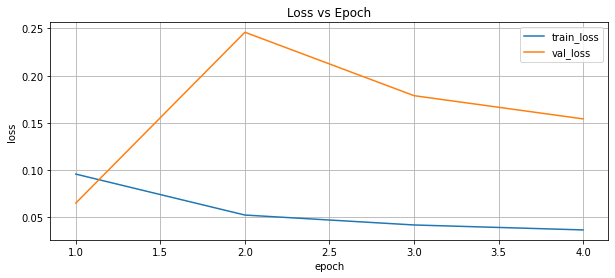

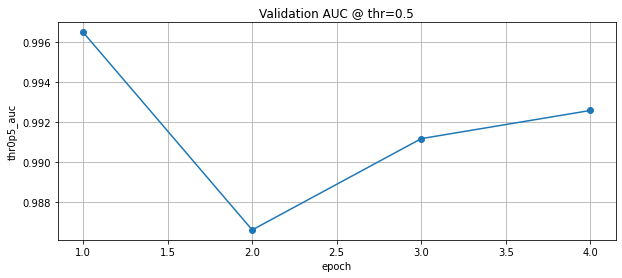

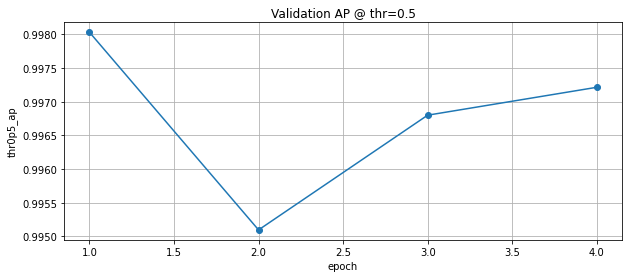

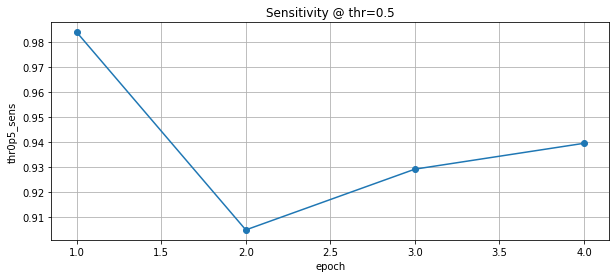

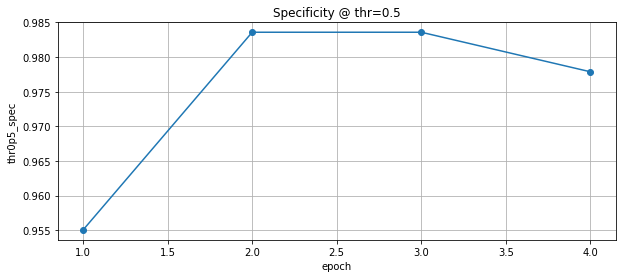

[val] loaded predictions from: best(csv) | n=4980


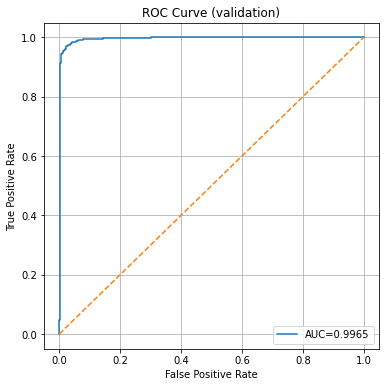

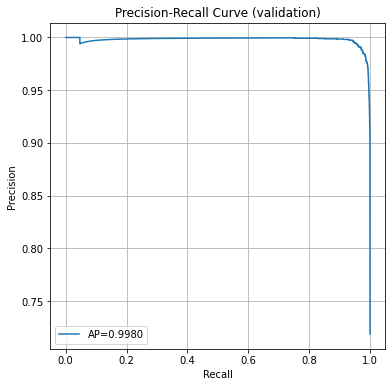

[metrics @ thr=0.5]
thr             0.500000
auc             0.996471
ap              0.998033
acc             0.975904
sens            0.984074
spec            0.955032
precision       0.982427
npv             0.959140
fpr             0.044968
fnr             0.015926
tn           1338.000000
fp             63.000000
fn             57.000000
tp           3522.000000
dtype: float64

[metrics @ best Youden threshold]
best_thr: 0.7362 J: 0.9464243298853112
thr             0.736171
auc             0.996471
ap              0.998033
acc             0.971486
sens            0.969265
spec            0.977159
precision       0.990860
npv             0.925625
fpr             0.022841
fnr             0.030735
tn           1369.000000
fp             32.000000
fn            110.000000
tp           3469.000000
dtype: float64

[errors] available epochs: [1, 2, 3, 4] | using epoch=4

[FP] count=31 | top slides:


slide_id
2024-04-09 14.23.49    29
1039408                 2
Name: count, dtype: int64


[FN] count=50 | top slides:


slide_id
2          45
1028748     3
1039408     2
Name: count, dtype: int64

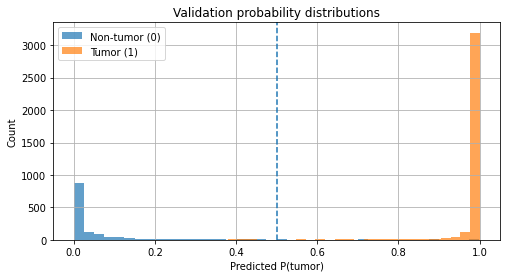


DONE ✅


In [1]:
# =========================
# Patch Model Analysis Notebook
# =========================

import os, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix
)

# -------------------------
# CONFIG
# -------------------------
MODEL_DIR = "results/model_patch"   # change if needed
EPOCH_FOR_ERRORS = None            # None -> auto pick max epoch found in hard_* files
THR = 0.50                         # threshold used for hard_fp/hard_fn CSVs

# -------------------------
# Utilities
# -------------------------
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

def safe_read_csv(path):
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"[warn] could not read {path}: {e}")
        return None

def find_best_val_arrays(model_dir):
    """Prefer val_predictions_best.csv; else fall back to val_y_best.npy + val_prob_best.npy; else last."""
    pred_best = os.path.join(model_dir, "val_predictions_best.csv")
    pred_last = os.path.join(model_dir, "val_predictions_last.csv")

    if os.path.exists(pred_best):
        df = pd.read_csv(pred_best)
        # expected cols: y_true, y_prob, (maybe) png_path, slide_id
        # try to detect column names robustly
        y_col = None
        p_col = None
        for c in df.columns:
            if c.lower() in ["y_true", "label", "gt", "true"]:
                y_col = c
            if c.lower() in ["y_prob", "prob", "p", "score"]:
                p_col = c
        if y_col is None or p_col is None:
            # fallback: first numeric-like columns
            num_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
            if len(num_cols) >= 2:
                y_col, p_col = num_cols[0], num_cols[1]
        if y_col is None or p_col is None:
            raise ValueError(f"Could not infer y_true/y_prob columns from {pred_best}. Columns: {df.columns.tolist()}")
        return df, df[y_col].to_numpy().astype(int), df[p_col].to_numpy().astype(float), "best(csv)"

    # numpy fallback
    y_best = os.path.join(model_dir, "val_y_best.npy")
    p_best = os.path.join(model_dir, "val_prob_best.npy")
    if os.path.exists(y_best) and os.path.exists(p_best):
        y = np.load(y_best).astype(int)
        p = np.load(p_best).astype(float)
        df = None
        return df, y, p, "best(npy)"

    # last fallback
    if os.path.exists(pred_last):
        df = pd.read_csv(pred_last)
        y_col = None
        p_col = None
        for c in df.columns:
            if c.lower() in ["y_true", "label", "gt", "true"]:
                y_col = c
            if c.lower() in ["y_prob", "prob", "p", "score"]:
                p_col = c
        if y_col is None or p_col is None:
            num_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
            if len(num_cols) >= 2:
                y_col, p_col = num_cols[0], num_cols[1]
        if y_col is None or p_col is None:
            raise ValueError(f"Could not infer y_true/y_prob columns from {pred_last}. Columns: {df.columns.tolist()}")
        return df, df[y_col].to_numpy().astype(int), df[p_col].to_numpy().astype(float), "last(csv)"

    y_last = os.path.join(model_dir, "val_y_last.npy")
    p_last = os.path.join(model_dir, "val_prob_last.npy")
    if os.path.exists(y_last) and os.path.exists(p_last):
        y = np.load(y_last).astype(int)
        p = np.load(p_last).astype(float)
        df = None
        return df, y, p, "last(npy)"

    raise FileNotFoundError("No validation prediction files found (val_predictions_*.csv or val_*_*.npy).")

def compute_basic_metrics(y_true, y_prob, thr=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    acc = (tp + tn) / max((tp + tn + fp + fn), 1)
    sens = tp / max((tp + fn), 1)
    spec = tn / max((tn + fp), 1)
    prec = tp / max((tp + fp), 1)
    npv  = tn / max((tn + fn), 1)
    fpr  = fp / max((fp + tn), 1)
    fnr  = fn / max((fn + tp), 1)
    ap   = average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan

    fpr_curve, tpr_curve, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr_curve, tpr_curve) if len(np.unique(y_true)) > 1 else np.nan

    return {
        "thr": thr,
        "auc": float(roc_auc),
        "ap": float(ap),
        "acc": float(acc),
        "sens": float(sens),
        "spec": float(spec),
        "precision": float(prec),
        "npv": float(npv),
        "fpr": float(fpr),
        "fnr": float(fnr),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

# -------------------------
# 1) Load history + summary
# -------------------------
history_path = os.path.join(MODEL_DIR, "history.json")
curves_path  = os.path.join(MODEL_DIR, "curves.json")
best_metrics_path = os.path.join(MODEL_DIR, "best_metrics.json")
train_summary_path = os.path.join(MODEL_DIR, "train_summary.json")

history = load_json(history_path) if os.path.exists(history_path) else None
curves = load_json(curves_path) if os.path.exists(curves_path) else None
best_metrics = load_json(best_metrics_path) if os.path.exists(best_metrics_path) else None
train_summary = load_json(train_summary_path) if os.path.exists(train_summary_path) else None

print("Loaded:")
print(" - history:", bool(history))
print(" - curves:", bool(curves))
print(" - best_metrics:", bool(best_metrics))
print(" - train_summary:", bool(train_summary))

# -------------------------
# 2) Plot training curves
# -------------------------
if history:
    dfh = pd.DataFrame(history)

    # detect columns (you have thr0p5_* and bestthr_* possibly)
    # We'll plot: train_loss, val_loss, thr0p5_auc, thr0p5_ap, thr0p5_sens/spec
    fig = plt.figure(figsize=(10,4))
    plt.plot(dfh["epoch"], dfh["train_loss"], label="train_loss")
    plt.plot(dfh["epoch"], dfh["val_loss"], label="val_loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Loss vs Epoch")
    plt.legend(); plt.grid(True); plt.show()

    def plot_metric(col, title):
        if col in dfh.columns:
            plt.figure(figsize=(10,4))
            plt.plot(dfh["epoch"], dfh[col], marker="o")
            plt.xlabel("epoch"); plt.ylabel(col)
            plt.title(title)
            plt.grid(True)
            plt.show()

    plot_metric("thr0p5_auc", "Validation AUC @ thr=0.5")
    plot_metric("thr0p5_ap",  "Validation AP @ thr=0.5")
    plot_metric("thr0p5_sens","Sensitivity @ thr=0.5")
    plot_metric("thr0p5_spec","Specificity @ thr=0.5")

# -------------------------
# 3) ROC + PR curves (from saved curves.json if present, else from val predictions)
# -------------------------
val_df, y_true, y_prob, src = find_best_val_arrays(MODEL_DIR)
print(f"[val] loaded predictions from: {src} | n={len(y_true)}")

# compute curves fresh (always correct)
fpr, tpr, roc_thr = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
prec, rec, pr_thr = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.4f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (validation)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.plot(rec, prec, label=f"AP={ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (validation)")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# 4) Confusion matrix @ thr=0.5 and best Youden threshold
# -------------------------
m05 = compute_basic_metrics(y_true, y_prob, thr=THR)
print("[metrics @ thr=0.5]")
print(pd.Series(m05))

# Youden threshold = argmax(tpr - fpr)
youden = (tpr - fpr)
best_i = int(np.argmax(youden))
best_thr = float(roc_thr[best_i])
m_best = compute_basic_metrics(y_true, y_prob, thr=best_thr)

print("\n[metrics @ best Youden threshold]")
print("best_thr:", round(best_thr, 4), "J:", float(youden[best_i]))
print(pd.Series(m_best))

# -------------------------
# 5) Hard FP/FN: load latest epoch files and summarize slides
# -------------------------
fp_files = sorted(glob.glob(os.path.join(MODEL_DIR, f"hard_fp_epoch*_thr{THR:.2f}.csv")))
fn_files = sorted(glob.glob(os.path.join(MODEL_DIR, f"hard_fn_epoch*_thr{THR:.2f}.csv")))

def infer_epoch(path):
    # hard_fp_epoch4_thr0.50.csv -> 4
    b = os.path.basename(path)
    return int(b.split("epoch")[1].split("_")[0])

if fp_files or fn_files:
    epochs = sorted(set([infer_epoch(p) for p in fp_files + fn_files]))
    ep = epochs[-1] if EPOCH_FOR_ERRORS is None else EPOCH_FOR_ERRORS
    print(f"\n[errors] available epochs: {epochs} | using epoch={ep}")

    fp_path = os.path.join(MODEL_DIR, f"hard_fp_epoch{ep}_thr{THR:.2f}.csv")
    fn_path = os.path.join(MODEL_DIR, f"hard_fn_epoch{ep}_thr{THR:.2f}.csv")

    df_fp = safe_read_csv(fp_path) if os.path.exists(fp_path) else None
    df_fn = safe_read_csv(fn_path) if os.path.exists(fn_path) else None

    def slide_error_summary(dfx, name):
        if dfx is None or len(dfx)==0:
            print(f"[{name}] none")
            return
        # try common slide id columns
        slide_col = None
        for c in dfx.columns:
            if c.lower() in ["slide_id", "slide", "sid"]:
                slide_col = c
                break
        if slide_col is None:
            # maybe embedded in png_path
            for c in dfx.columns:
                if "path" in c.lower():
                    slide_col = c
                    break
        if slide_col is None:
            print(f"[{name}] cannot infer slide column. cols={dfx.columns.tolist()}")
            return

        if "path" in slide_col.lower():
            # parse slide_id from filename
            tmp = dfx.copy()
            tmp["slide_id"] = tmp[slide_col].apply(lambda p: os.path.basename(p).split("__x")[0] if isinstance(p,str) else "NA")
            slide_col = "slide_id"
            dfx = tmp

        top = dfx[slide_col].value_counts().head(15)
        print(f"\n[{name}] count={len(dfx)} | top slides:")
        display(top)

    # In notebooks, display exists; if not, fallback:
    try:
        from IPython.display import display
    except:
        display = print

    slide_error_summary(df_fp, "FP")
    slide_error_summary(df_fn, "FN")

else:
    print("\n[errors] No hard_fp/hard_fn files found.")

# -------------------------
# 6) (Optional) score histogram by class
# -------------------------
plt.figure(figsize=(8,4))
plt.hist(y_prob[y_true==0], bins=40, alpha=0.7, label="Non-tumor (0)")
plt.hist(y_prob[y_true==1], bins=40, alpha=0.7, label="Tumor (1)")
plt.axvline(THR, linestyle="--")
plt.xlabel("Predicted P(tumor)")
plt.ylabel("Count")
plt.title("Validation probability distributions")
plt.legend()
plt.grid(True)
plt.show()

print("\nDONE ✅")